In [1]:
#IMPORTS

import torch
import timm
import pandas as pd

In [2]:
#DEVICE

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [3]:

#LOAD MODELS

mobilevit_model = timm.create_model(
    "mobilevit_s",
    pretrained=False,
    num_classes=7
)

tinyvit_model = timm.create_model(
    "tiny_vit_5m_224",
    pretrained=False,
    num_classes=7
)

In [4]:
#PARAMETER COUNT FUNCTION

def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
    )

In [8]:
#COUNT PARAMETERS

mobilevit_params = count_parameters(
    mobilevit_model
)

tinyvit_params = count_parameters(
    tinyvit_model
)

print(f"MobileViT Parameters: {mobilevit_params:,}")

print(f"TinyViT Parameters: {tinyvit_params:,}")

MobileViT Parameters: 4,942,119
TinyViT Parameters: 5,074,011


In [12]:
#CREATE TABLE

efficiency_df = pd.DataFrame({
    "Model": [
        "MobileViT",
        "TinyViT"
    ],

    "Parameters": [
        mobilevit_params,
        tinyvit_params
    ]
})

efficiency_df

,Model,Parameters
0,MobileViT,4942119
1,TinyViT,5074011


In [13]:
#SAVE TABLE

import os

# Create folders
os.makedirs(
    "/kaggle/working/outputs/reports",
    exist_ok=True
)

# Save CSV
efficiency_df.to_csv(
    "/kaggle/working/outputs/reports/efficiency_analysis.csv",
    index=False
)

print("Efficiency analysis saved successfully.")

print(
    os.path.abspath(
        "/kaggle/working/outputs/reports/efficiency_analysis.csv"
    )
)

Efficiency analysis saved successfully.
/kaggle/working/outputs/reports/efficiency_analysis.csv


In [14]:
#INFERENCE SPEED

In [15]:
import time

In [16]:
#DUMMY INPUT
dummy_input = torch.randn(
    1,
    3,
    224,
    224
).to(device)

In [17]:
#MOVE MODELS TO DEVICE

mobilevit_model.to(device)

tinyvit_model.to(device)

mobilevit_model.eval()

tinyvit_model.eval()

TinyVit(
  (patch_embed): PatchEmbed(
    (conv1): ConvNorm(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (act): GELU(approximate='none')
    (conv2): ConvNorm(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (stages): Sequential(
    (0): ConvLayer(
      (blocks): Sequential(
        (0): MBConv(
          (conv1): ConvNorm(
            (conv): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (act1): GELU(approximate='none')
          (conv2): ConvNorm(
            (conv): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=256, bias=Fals

In [18]:
#INFERENCE FUNCTION

def measure_inference_time(model):

    starter = time.time()

    with torch.no_grad():

        for _ in range(100):

            _ = model(dummy_input)

    ender = time.time()

    avg_time = (ender - starter) / 100

    return avg_time * 1000

In [19]:
#RUN BENCHMARK

mobilevit_time = measure_inference_time(
    mobilevit_model
)

tinyvit_time = measure_inference_time(
    tinyvit_model
)

print(f"MobileViT Avg Inference: {mobilevit_time:.2f} ms")

print(f"TinyViT Avg Inference: {tinyvit_time:.2f} ms")

MobileViT Avg Inference: 16.59 ms
TinyViT Avg Inference: 9.25 ms


In [20]:
#ADD TO TABLE

efficiency_df["Inference Time (ms)"] = [
    mobilevit_time,
    tinyvit_time
]

efficiency_df

,Model,Parameters,Inference Time (ms)
0,MobileViT,4942119,16.590223
1,TinyViT,5074011,9.246838


In [21]:
import os

os.makedirs(
    "/kaggle/working/outputs/reports",
    exist_ok=True
)

efficiency_df.to_csv(
    "/kaggle/working/outputs/reports/efficiency_analysis.csv",
    index=False
)

print("Efficiency analysis saved successfully.")

Efficiency analysis saved successfully.


In [22]:
os.makedirs(
    "/kaggle/working/outputs/figures",
    exist_ok=True
)

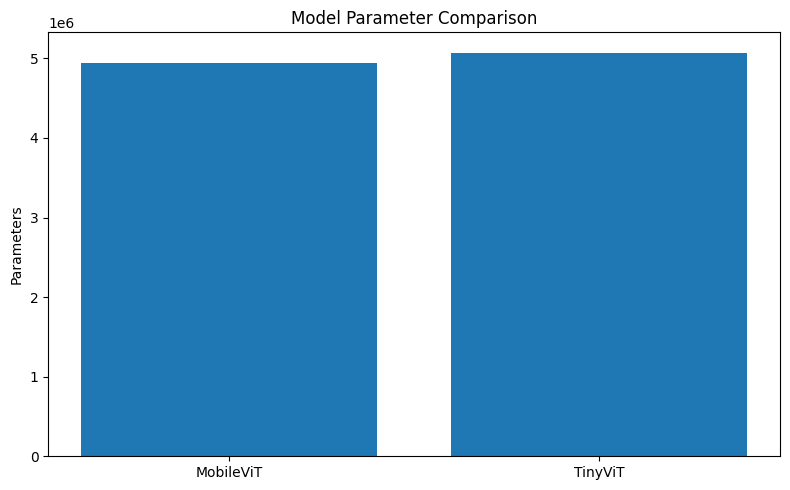

Parameter comparison figure saved successfully.


In [23]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 5))

plt.bar(
    efficiency_df["Model"],
    efficiency_df["Parameters"]
)

plt.title("Model Parameter Comparison")

plt.ylabel("Parameters")

plt.tight_layout()

fig.savefig(
    "/kaggle/working/outputs/figures/parameter_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.close(fig)

print("Parameter comparison figure saved successfully.")

In [24]:
report = f"""
Efficiency Analysis Report

MobileViT
Parameters: {mobilevit_params:,}
Average Inference Time: {mobilevit_time:.2f} ms

TinyViT
Parameters: {tinyvit_params:,}
Average Inference Time: {tinyvit_time:.2f} ms

Observations:
- Both models are lightweight transformer architectures.
- TinyViT achieved competitive efficiency with slightly higher parameter count.
- Lightweight ViTs are suitable for efficient medical image classification tasks.
"""

with open(
    "/kaggle/working/outputs/reports/efficiency_analysis_report.txt",
    "w"
) as f:

    f.write(report)

print("Efficiency analysis report saved successfully.")

Efficiency analysis report saved successfully.


In [25]:
import shutil

shutil.make_archive(
    "/kaggle/working/project_outputs",
    'zip',
    "/kaggle/working/outputs"
)

print("ZIP file created successfully.")

ZIP file created successfully.
